In [2]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

## Fine-tuning on NQ with reformulated labels?

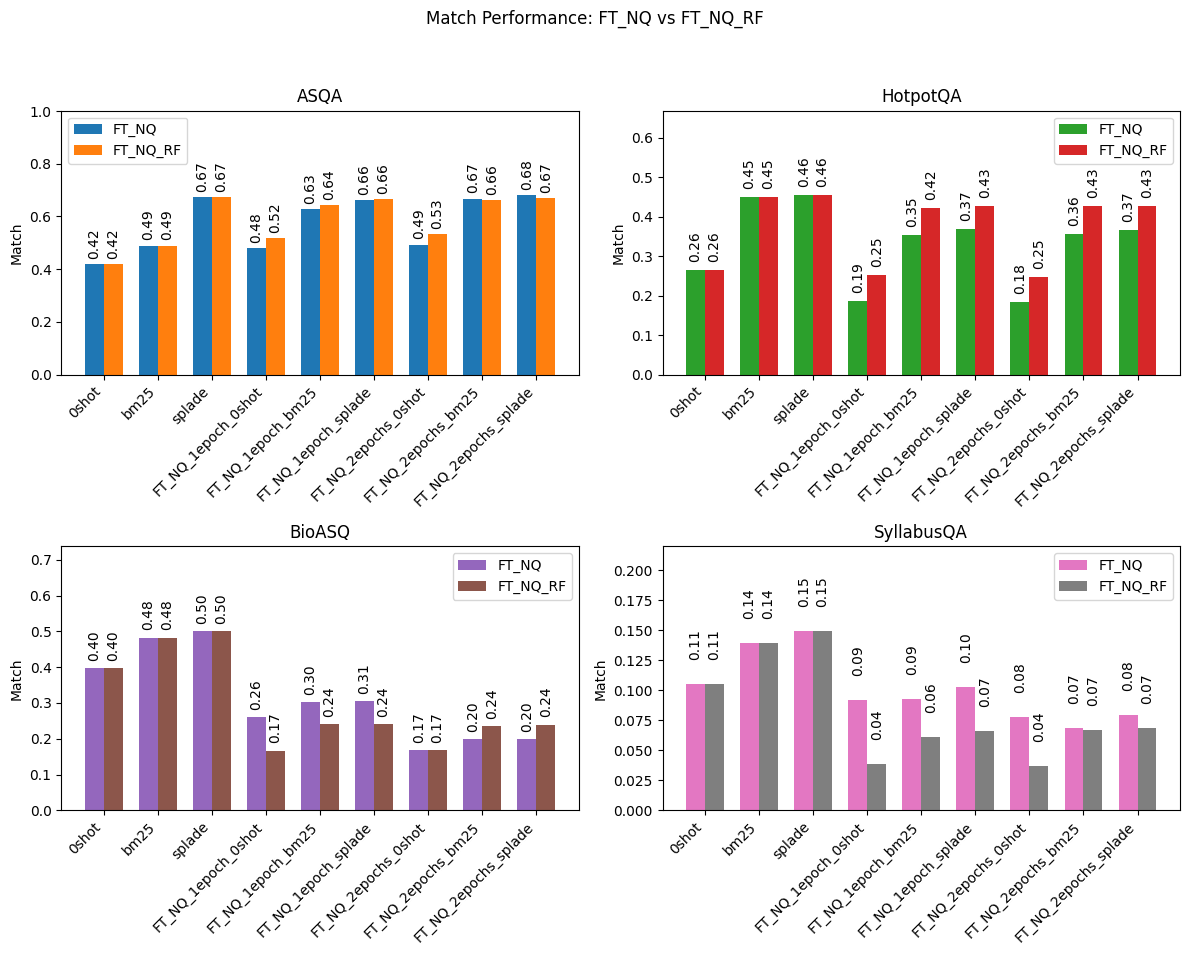

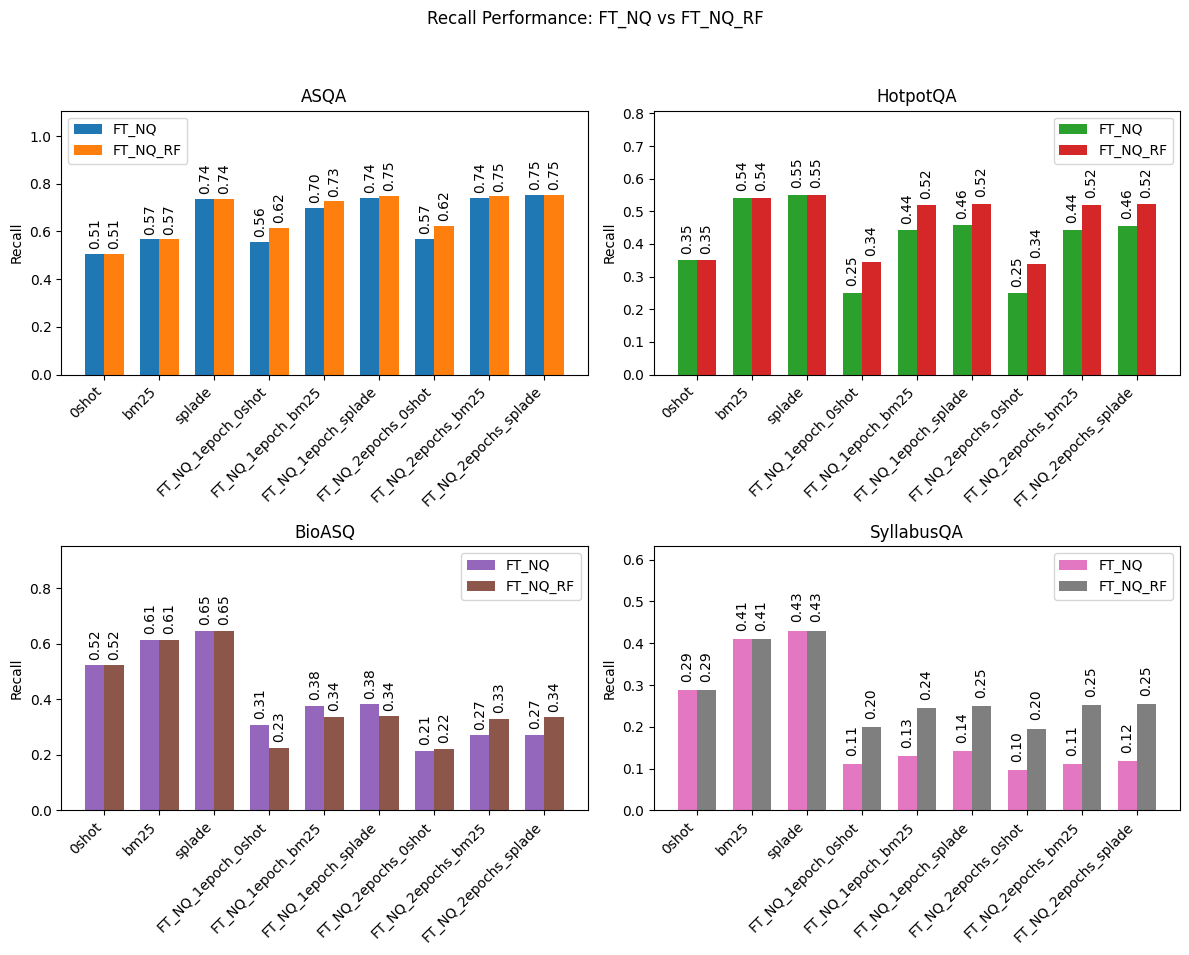

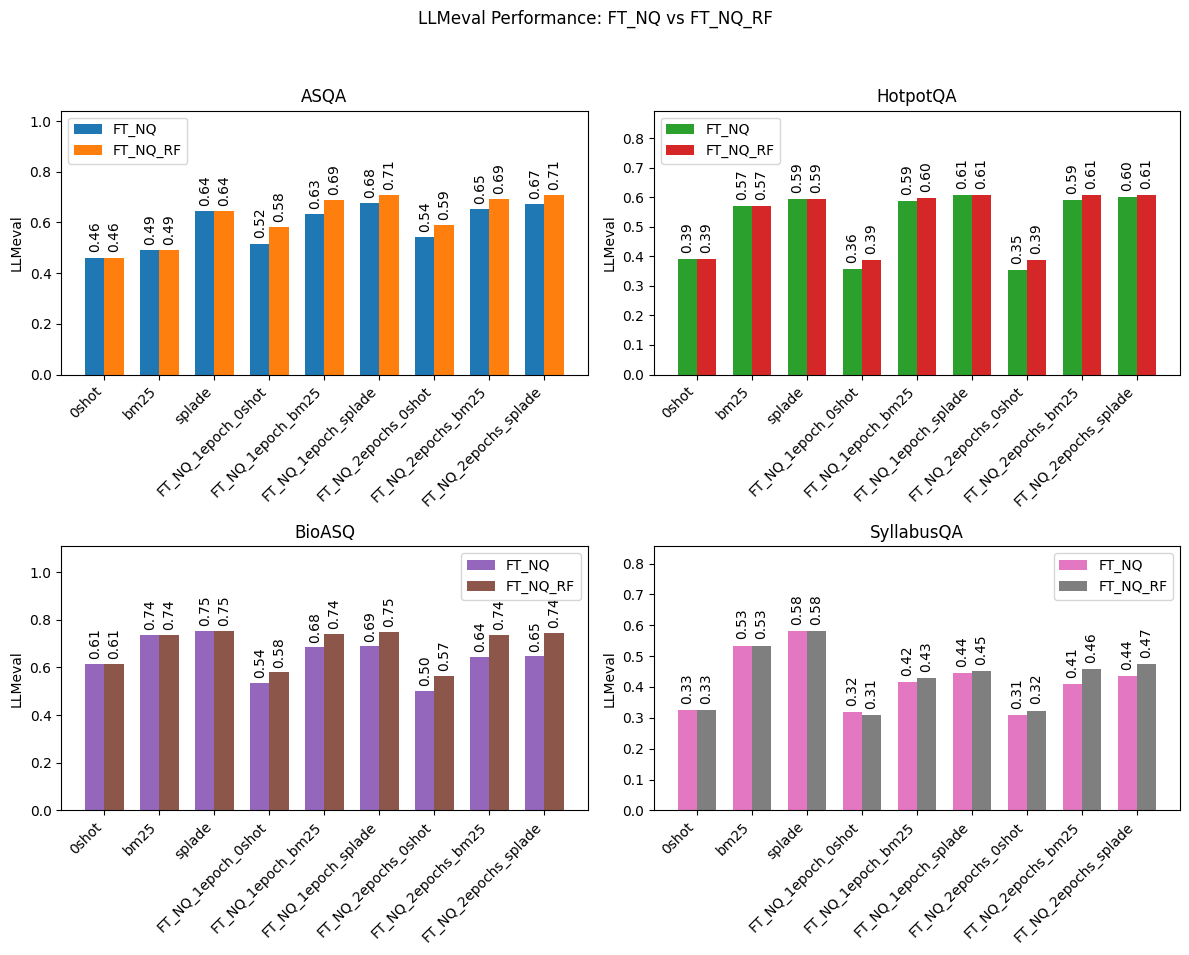

In [3]:
# Define experiment directories for FT_NQ and FT_NQ_RF
FT_NQ_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_1epoch_0shot',
    'll3_8b_FT_NQ_1epoch_bm25',
    'll3_8b_FT_NQ_1epoch_splade',
    'll3_8b_FT_NQ_2epochs_0shot',
    'll3_8b_FT_NQ_2epochs_bm25',
    'll3_8b_FT_NQ_2epochs_splade',
]

FT_NQ_RF_labels_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_RF_short_1epoch_0shot',
    'll3_8b_FT_NQ_RF_short_1epoch_bm25',
    'll3_8b_FT_NQ_RF_short_1epoch_splade',
    'll3_8b_FT_NQ_RF_short_2epochs_0shot',
    'll3_8b_FT_NQ_RF_short_2epochs_bm25',
    'll3_8b_FT_NQ_RF_short_2epochs_splade',
]

# Root directory where experiment results are stored (4 datasets)
dataset_dirs = [
    'experiments/FT/asqa',
    'experiments/FT/hotpotqa',
    'experiments/FT/bioasq',
    'experiments/FT/syllabusqa'
]

dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics for a given experiment directory and dataset
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()

    # Define colors for each dataset pair
    colors = [
        ('#1f77b4', '#ff7f0e'),  # Dataset 1 colors (blue, orange)
        ('#2ca02c', '#d62728'),  # Dataset 2 colors (green, red)
        ('#9467bd', '#8c564b'),  # Dataset 3 colors (purple, brown)
        ('#e377c2', '#7f7f7f'),  # Dataset 4 colors (pink, gray)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.35
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ and FT_NQ_RF for the dataset
        bar1 = ax.bar(x - bar_width/2, nq_data[i], bar_width, label='FT_NQ', color=colors[i][0])
        bar2 = ax.bar(x + bar_width/2, nq_rf_data[i], bar_width, label='FT_NQ_RF', color=colors[i][1])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # increase y_max to fit vertical numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        
        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Collect data for both NQ and NQ with Reformulated labels per dataset
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for FT_NQ and FT_NQ_RF experiments
nq_matches, nq_recalls, nq_llmevals = collect_experiment_data_per_dataset(FT_NQ_experiments, dataset_dirs)
nq_rf_matches, nq_rf_recalls, nq_rf_llmevals = collect_experiment_data_per_dataset(FT_NQ_RF_labels_experiments, dataset_dirs)

# Define experiment labels (using only the name part after 'll3_8b_')
experiment_labels = [exp[7:] for exp in FT_NQ_experiments]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', nq_matches, nq_rf_matches, experiment_labels, 'Match Performance: FT_NQ vs FT_NQ_RF', dataset_names)
plot_metrics_bar_subplots('Recall', nq_recalls, nq_rf_recalls, experiment_labels, 'Recall Performance: FT_NQ vs FT_NQ_RF', dataset_names)
plot_metrics_bar_subplots('LLMeval', nq_llmevals, nq_rf_llmevals, experiment_labels, 'LLMeval Performance: FT_NQ vs FT_NQ_RF', dataset_names)


## Better fine-tune on NQ or MultiQA ?

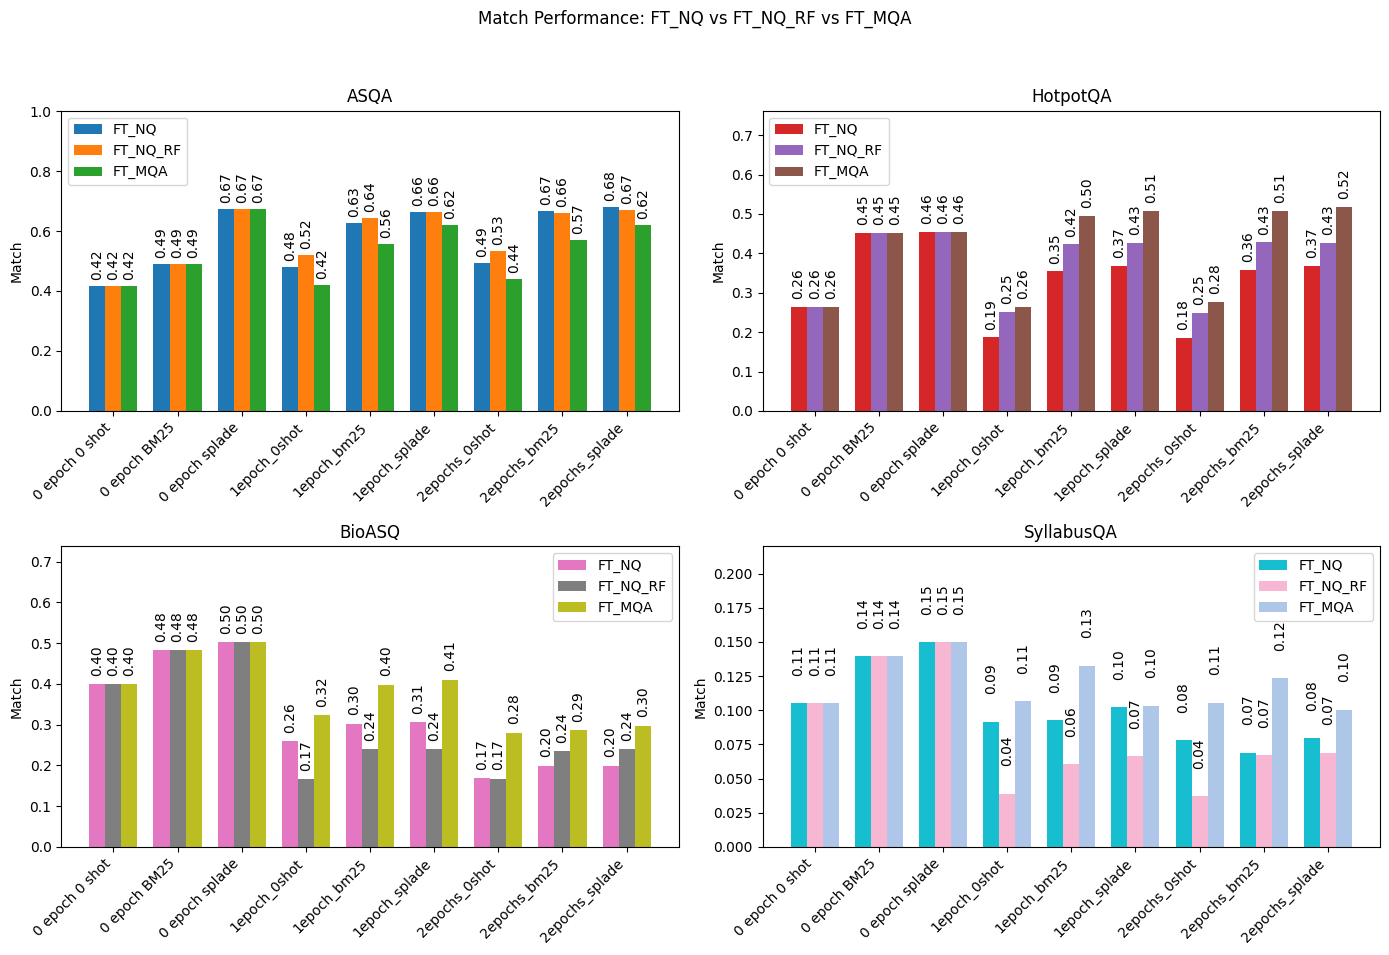

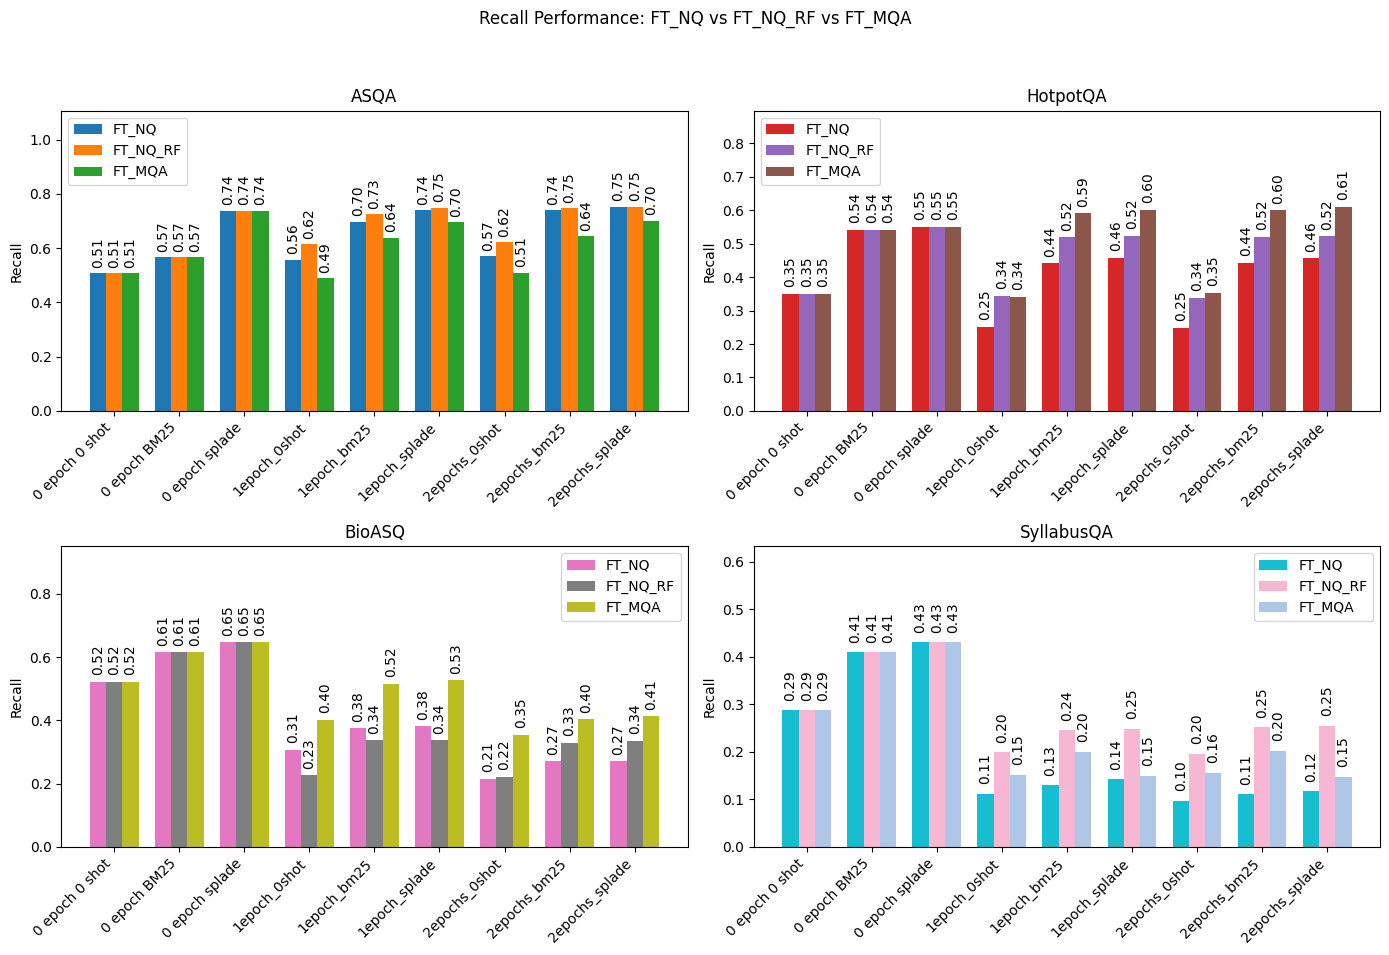

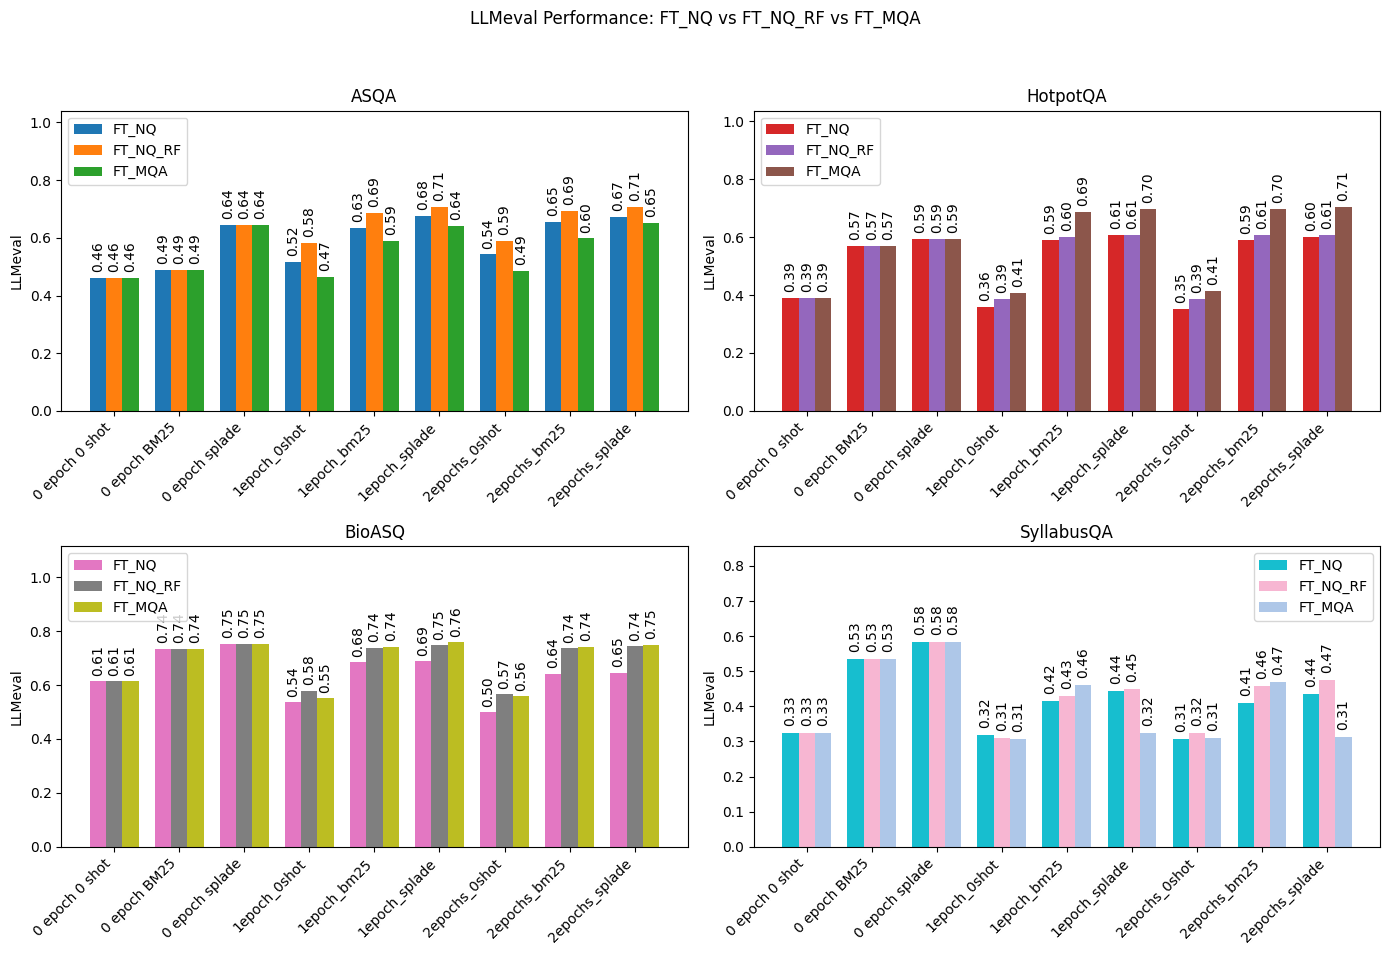

In [5]:
# Experiments lists
FT_NQ_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_1epoch_0shot',
    'll3_8b_FT_NQ_1epoch_bm25',
    'll3_8b_FT_NQ_1epoch_splade',
    'll3_8b_FT_NQ_2epochs_0shot',
    'll3_8b_FT_NQ_2epochs_bm25',
    'll3_8b_FT_NQ_2epochs_splade',
]

FT_NQ_RF_labels_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_RF_short_1epoch_0shot',
    'll3_8b_FT_NQ_RF_short_1epoch_bm25',
    'll3_8b_FT_NQ_RF_short_1epoch_splade',
    'll3_8b_FT_NQ_RF_short_2epochs_0shot',
    'll3_8b_FT_NQ_RF_short_2epochs_bm25',
    'll3_8b_FT_NQ_RF_short_2epochs_splade',
]

FT_MQA_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_BM25_11K_splade',
]

# Dataset names
dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics function
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Function for collecting data
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for FT_NQ, FT_NQ_RF, and FT_MQA experiments
nq_matches, nq_recalls, nq_llmevals = collect_experiment_data_per_dataset(FT_NQ_experiments, dataset_dirs)
nq_rf_matches, nq_rf_recalls, nq_rf_llmevals = collect_experiment_data_per_dataset(FT_NQ_RF_labels_experiments, dataset_dirs)
mqa_matches, mqa_recalls, mqa_llmevals = collect_experiment_data_per_dataset(FT_MQA_experiments, dataset_dirs)

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, mqa_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    # Define colors for each dataset triplet
    colors = [
        ('#1f77b4', '#ff7f0e', '#2ca02c'),  # Dataset 1 colors (blue, orange, green)
        ('#d62728', '#9467bd', '#8c564b'),  # Dataset 2 colors (red, purple, brown)
        ('#e377c2', '#7f7f7f', '#bcbd22'),  # Dataset 3 colors (pink, gray, yellow)
        ('#17becf', '#f7b6d2', '#aec7e8'),  # Dataset 4 colors (cyan, light pink, light blue)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.25
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ, FT_NQ_RF, and FT_MQA for the dataset
        bar1 = ax.bar(x - bar_width, nq_data[i], bar_width, label='FT_NQ', color=colors[i][0])
        bar2 = ax.bar(x, nq_rf_data[i], bar_width, label='FT_NQ_RF', color=colors[i][1])
        bar3 = ax.bar(x + bar_width, mqa_data[i], bar_width, label='FT_MQA', color=colors[i][2])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        for rect in bar3:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # Adjust y-axis limits to fit numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Define experiment labels (shortened)
experiment_labels = ["0 epoch 0 shot", "0 epoch BM25", "0 epoch splade"] + [exp[13:] for exp in FT_NQ_experiments[3:]]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', nq_matches, nq_rf_matches, mqa_matches, experiment_labels, 'Match Performance: FT_NQ vs FT_NQ_RF vs FT_MQA', dataset_names)
plot_metrics_bar_subplots('Recall', nq_recalls, nq_rf_recalls, mqa_recalls, experiment_labels, 'Recall Performance: FT_NQ vs FT_NQ_RF vs FT_MQA', dataset_names)
plot_metrics_bar_subplots('LLMeval', nq_llmevals, nq_rf_llmevals, mqa_llmevals, experiment_labels, 'LLMeval Performance: FT_NQ vs FT_NQ_RF vs FT_MQA', dataset_names)


## Fine-tuning with or without distractors?

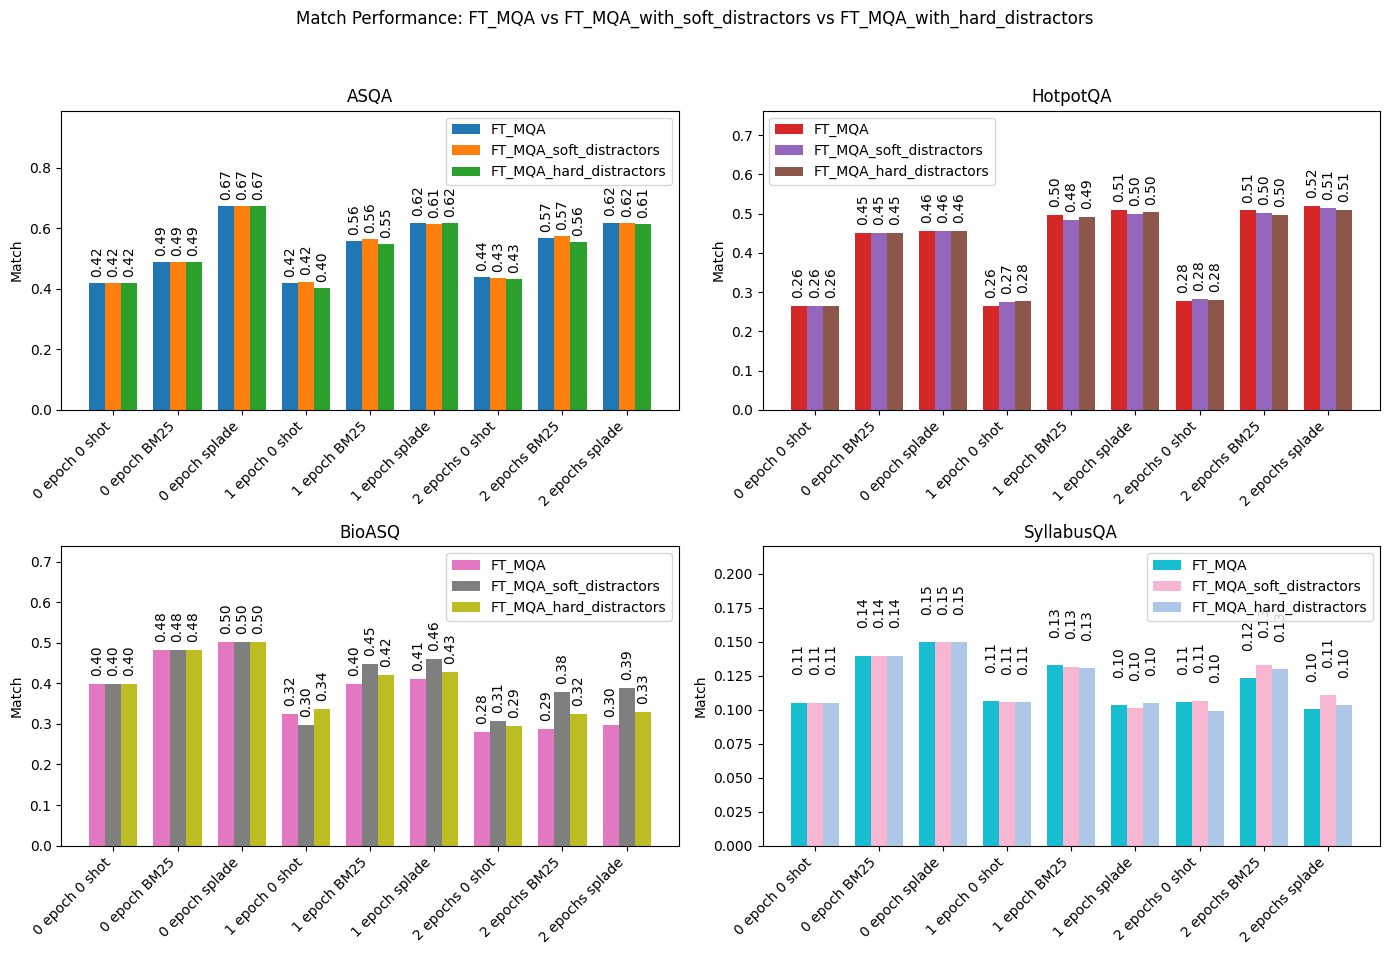

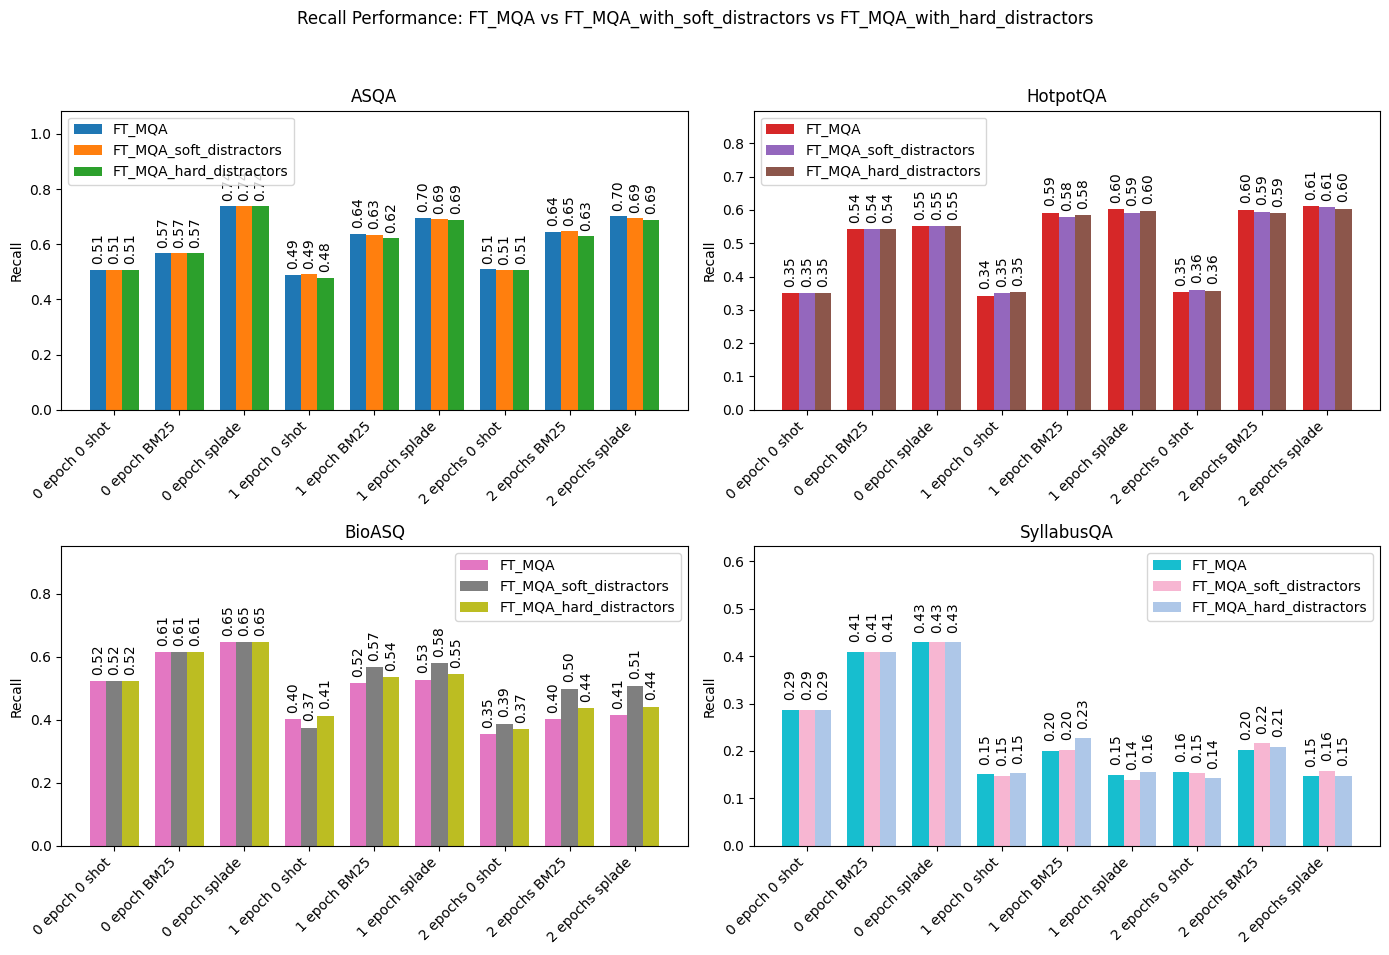

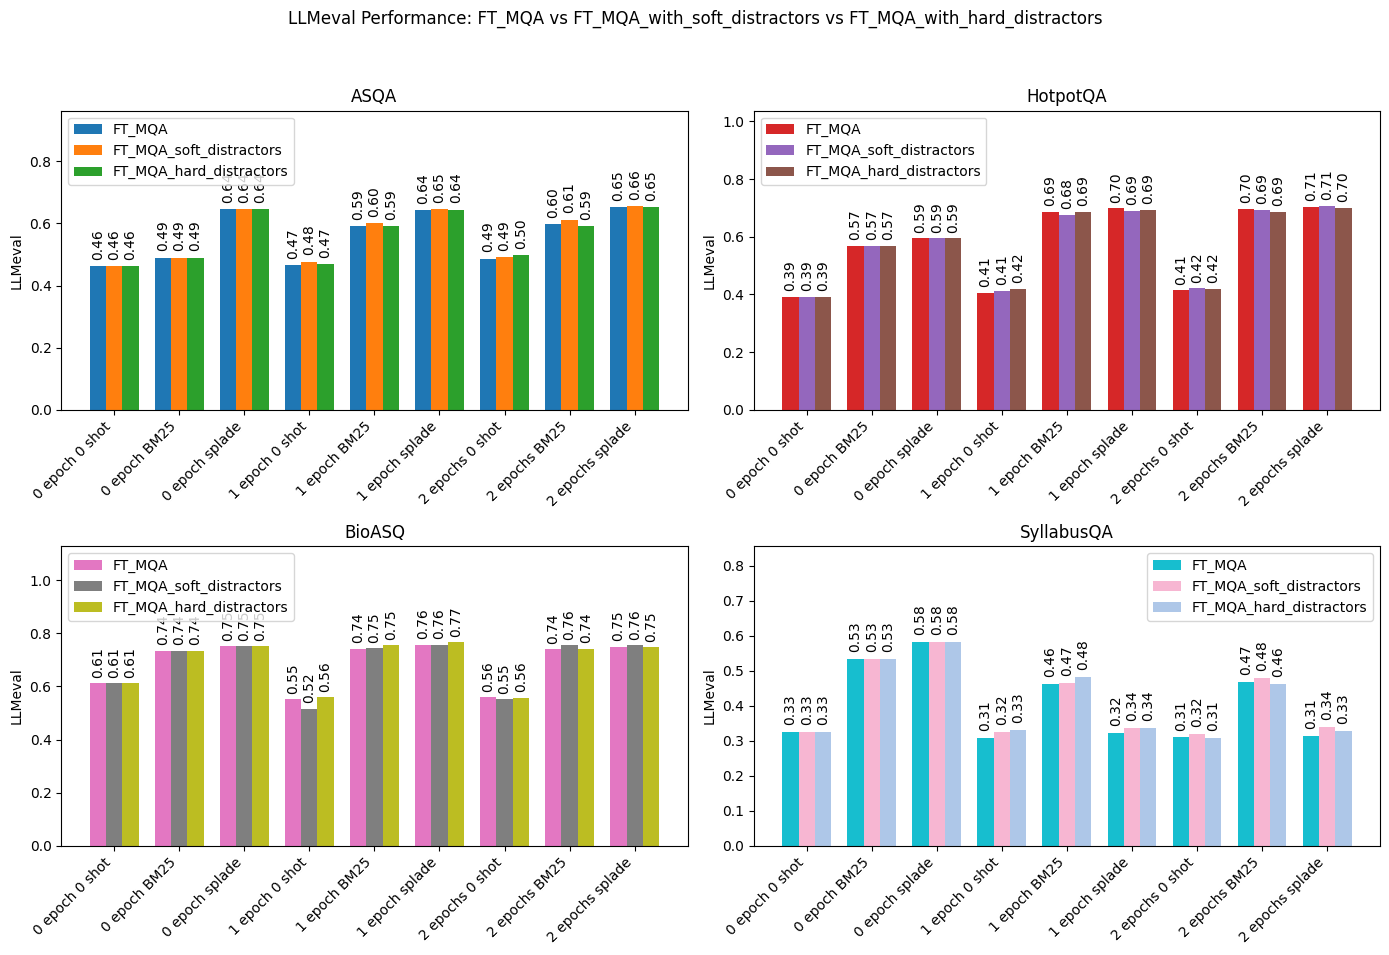

In [6]:
FT_MQA_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_BM25_11K_splade',
    ]

FT_MQA_with_soft_distractors_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_splade',
]

FT_MQA_with_hard_distractors_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_splade',
]

# Dataset names
dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics function
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Function for collecting data
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

mqa_matches, mqa_recalls, mqa_llmevals = collect_experiment_data_per_dataset(FT_MQA_experiments, dataset_dirs)
mqa_with_soft_distractors_matches, mqa_with_soft_distractors_recalls, mqa_with_soft_distractors_llmevals = collect_experiment_data_per_dataset(FT_MQA_with_soft_distractors_experiments, dataset_dirs)
mqa_with_hard_distractors_matches, mqa_with_hard_distractors_recalls, mqa_with_hard_distractors_llmevals = collect_experiment_data_per_dataset(FT_MQA_with_hard_distractors_experiments, dataset_dirs)

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, mqa_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    # Define colors for each dataset triplet
    colors = [
        ('#1f77b4', '#ff7f0e', '#2ca02c'),  # Dataset 1 colors (blue, orange, green)
        ('#d62728', '#9467bd', '#8c564b'),  # Dataset 2 colors (red, purple, brown)
        ('#e377c2', '#7f7f7f', '#bcbd22'),  # Dataset 3 colors (pink, gray, yellow)
        ('#17becf', '#f7b6d2', '#aec7e8'),  # Dataset 4 colors (cyan, light pink, light blue)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.25
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ, FT_NQ_RF, and FT_MQA for the dataset
        bar1 = ax.bar(x - bar_width, nq_data[i], bar_width, label='FT_MQA', color=colors[i][0])
        bar2 = ax.bar(x, nq_rf_data[i], bar_width, label='FT_MQA_soft_distractors', color=colors[i][1])
        bar3 = ax.bar(x + bar_width, mqa_data[i], bar_width, label='FT_MQA_hard_distractors', color=colors[i][2])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        for rect in bar3:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # Adjust y-axis limits to fit numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Define experiment labels (shortened)
experiment_labels = ["0 epoch 0 shot", "0 epoch BM25", "0 epoch splade"] +\
      ["1 epoch 0 shot", "1 epoch BM25", "1 epoch splade"] +\
      ["2 epochs 0 shot", "2 epochs BM25", "2 epochs splade"]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', mqa_matches, mqa_with_soft_distractors_matches, mqa_with_hard_distractors_matches, experiment_labels, 'Match Performance: FT_MQA vs FT_MQA_with_soft_distractors vs FT_MQA_with_hard_distractors', dataset_names)
plot_metrics_bar_subplots('Recall', mqa_recalls, mqa_with_soft_distractors_recalls, mqa_with_hard_distractors_recalls, experiment_labels, 'Recall Performance: FT_MQA vs FT_MQA_with_soft_distractors vs FT_MQA_with_hard_distractors', dataset_names)
plot_metrics_bar_subplots('LLMeval', mqa_llmevals, mqa_with_soft_distractors_llmevals, mqa_with_hard_distractors_llmevals, experiment_labels, 'LLMeval Performance: FT_MQA vs FT_MQA_with_soft_distractors vs FT_MQA_with_hard_distractors', dataset_names)


## Fine-tuning on bm25 or on splade?

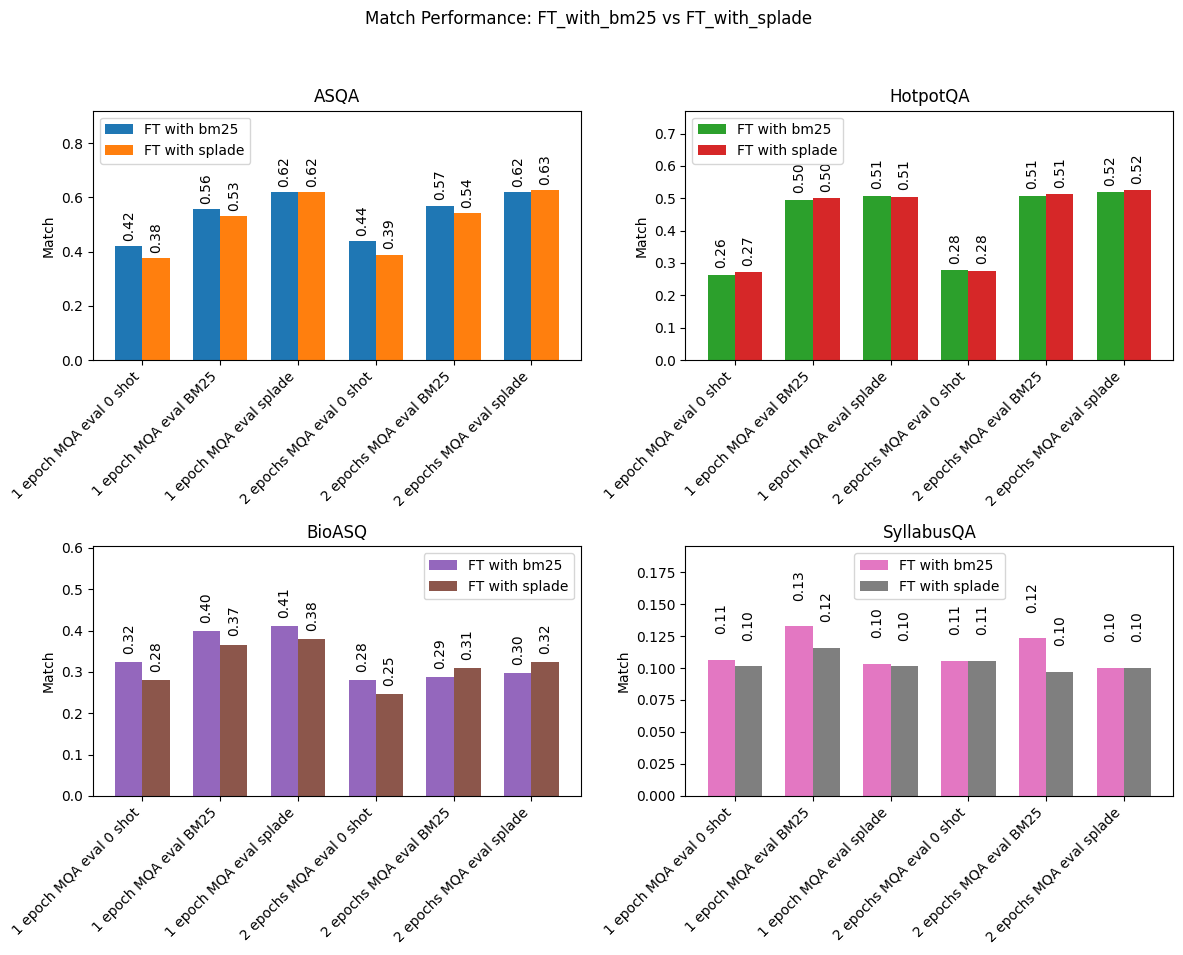

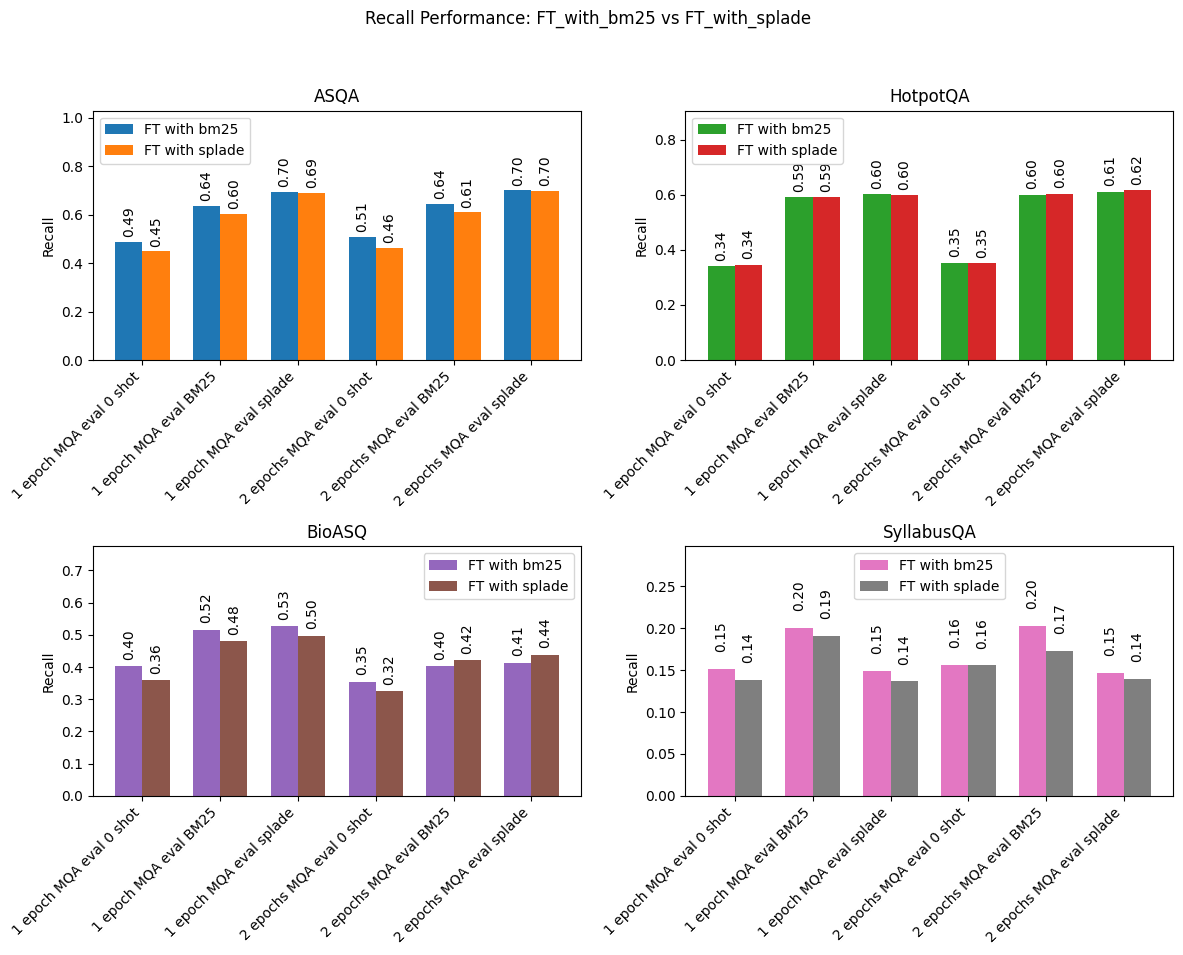

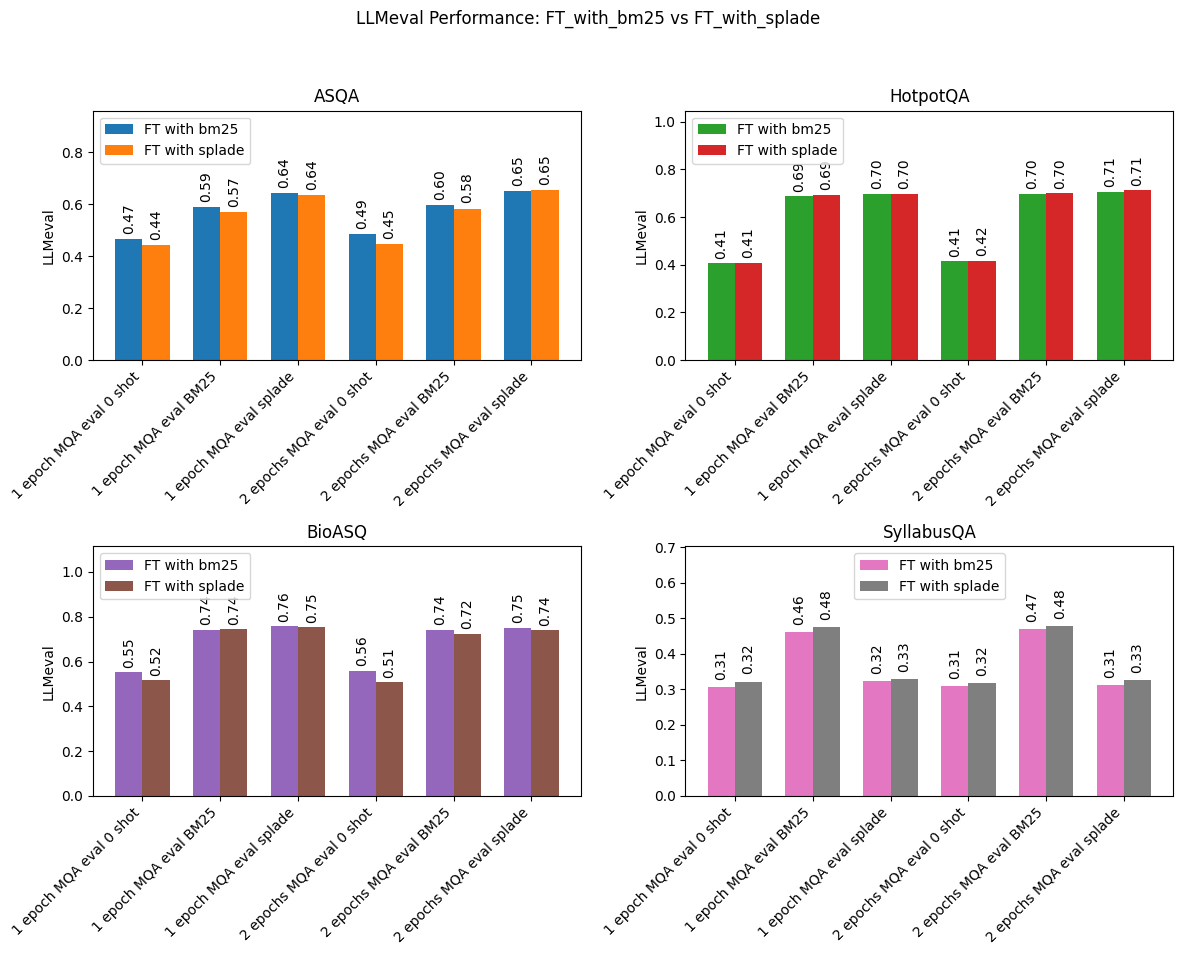

In [3]:
FT_bm25 = [
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_BM25_11K_splade',
    ]

FT_splade = [
    'll3_8b_FT_MQA_splade_5K_0shot',
    'll3_8b_FT_MQA_splade_5K_bm25',
    'll3_8b_FT_MQA_splade_5K_splade',
    'll3_8b_FT_MQA_splade_11K_0shot',
    'll3_8b_FT_MQA_splade_11K_bm25',
    'll3_8b_FT_MQA_splade_11K_splade',
    ]

# Root directory where experiment results are stored (4 datasets)
dataset_dirs = [
    'experiments/FT/asqa',
    'experiments/FT/hotpotqa',
    'experiments/FT/bioasq',
    'experiments/FT/syllabusqa'
]

dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics for a given experiment directory and dataset
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()

    # Define colors for each dataset pair
    colors = [
        ('#1f77b4', '#ff7f0e'),  # Dataset 1 colors (blue, orange)
        ('#2ca02c', '#d62728'),  # Dataset 2 colors (green, red)
        ('#9467bd', '#8c564b'),  # Dataset 3 colors (purple, brown)
        ('#e377c2', '#7f7f7f'),  # Dataset 4 colors (pink, gray)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.35
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ and FT_NQ_RF for the dataset
        bar1 = ax.bar(x - bar_width/2, nq_data[i], bar_width, label='FT with bm25', color=colors[i][0])
        bar2 = ax.bar(x + bar_width/2, nq_rf_data[i], bar_width, label='FT with splade', color=colors[i][1])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # increase y_max to fit vertical numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        
        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Collect data for both NQ and NQ with Reformulated labels per dataset
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for FT_NQ and FT_NQ_RF experiments
FT_bm25_matches, FT_bm25_recalls, FT_bm25_llmevals = collect_experiment_data_per_dataset(FT_bm25, dataset_dirs)
FT_splade_matches, FT_splade_recalls, FT_splade_llmevals = collect_experiment_data_per_dataset(FT_splade, dataset_dirs)

# Define experiment labels (using only the name part after 'll3_8b_')
experiment_labels = ["1 epoch MQA eval 0 shot", "1 epoch MQA eval BM25", "1 epoch MQA eval splade"] +\
      ["2 epochs MQA eval 0 shot", "2 epochs MQA eval BM25", "2 epochs MQA eval splade"]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', FT_bm25_matches, FT_splade_matches, experiment_labels, 'Match Performance: FT_with_bm25 vs FT_with_splade', dataset_names)
plot_metrics_bar_subplots('Recall', FT_bm25_recalls, FT_splade_recalls, experiment_labels, 'Recall Performance: FT_with_bm25 vs FT_with_splade', dataset_names)
plot_metrics_bar_subplots('LLMeval', FT_bm25_llmevals, FT_splade_llmevals, experiment_labels, 'LLMeval Performance: FT_with_bm25 vs FT_with_splade', dataset_names)


## At test-time: 0-shot vs BM25 vs Splade

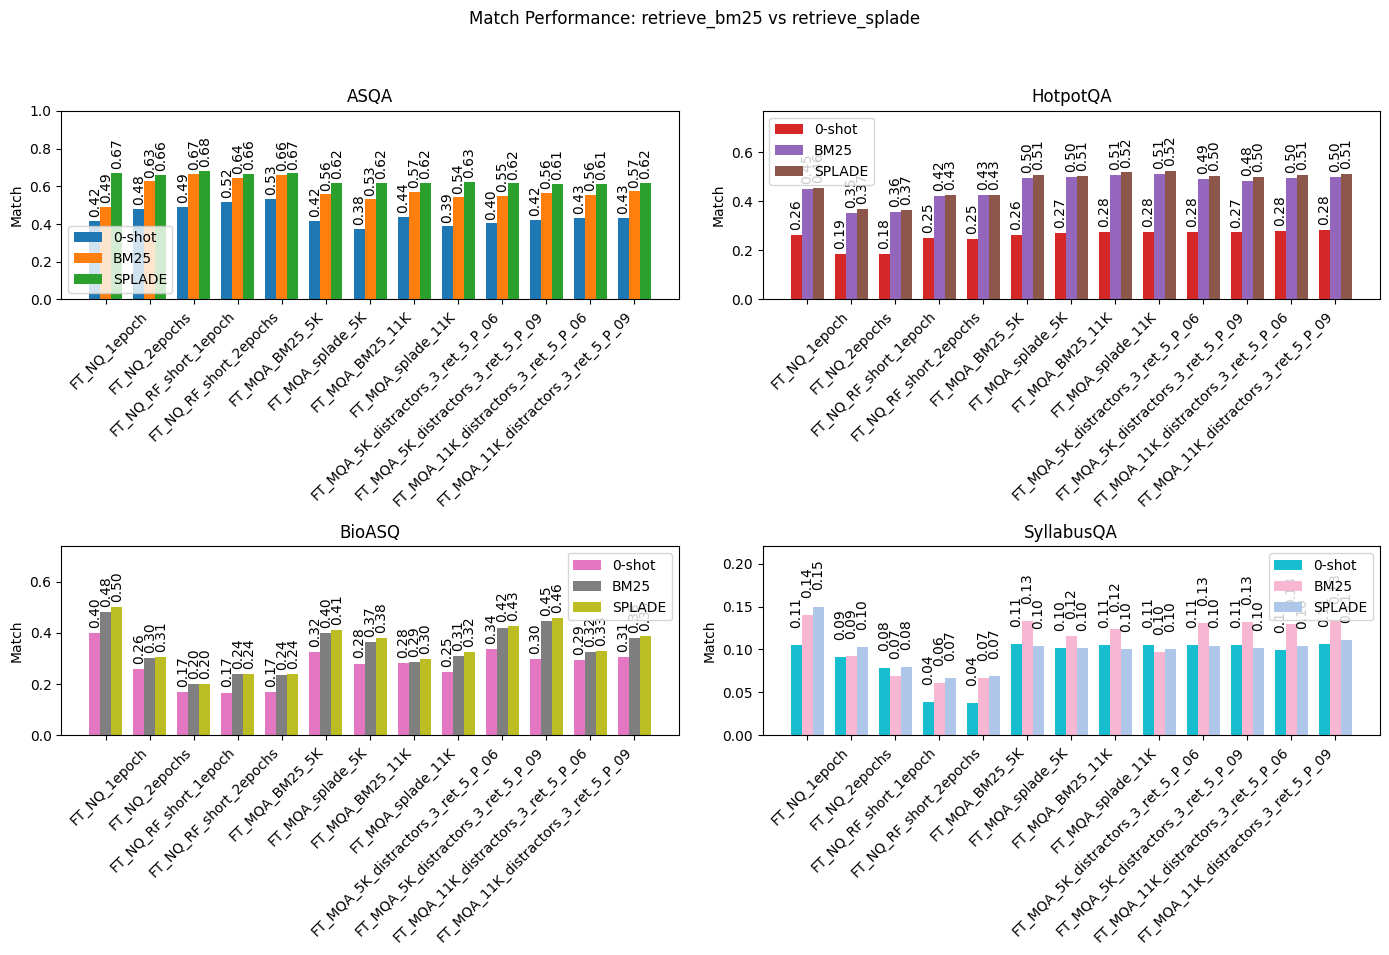

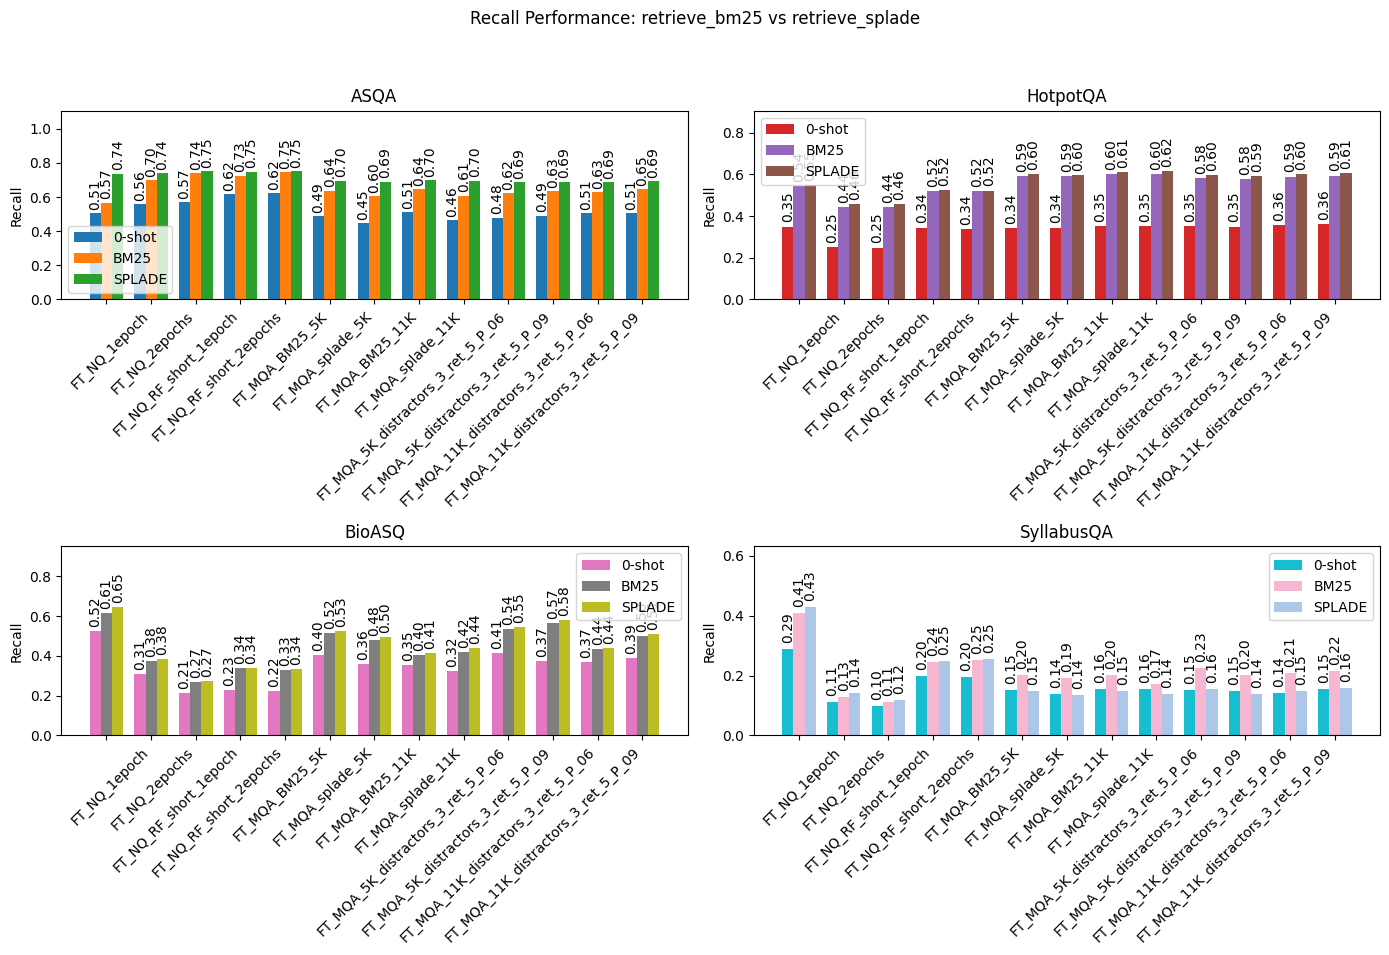

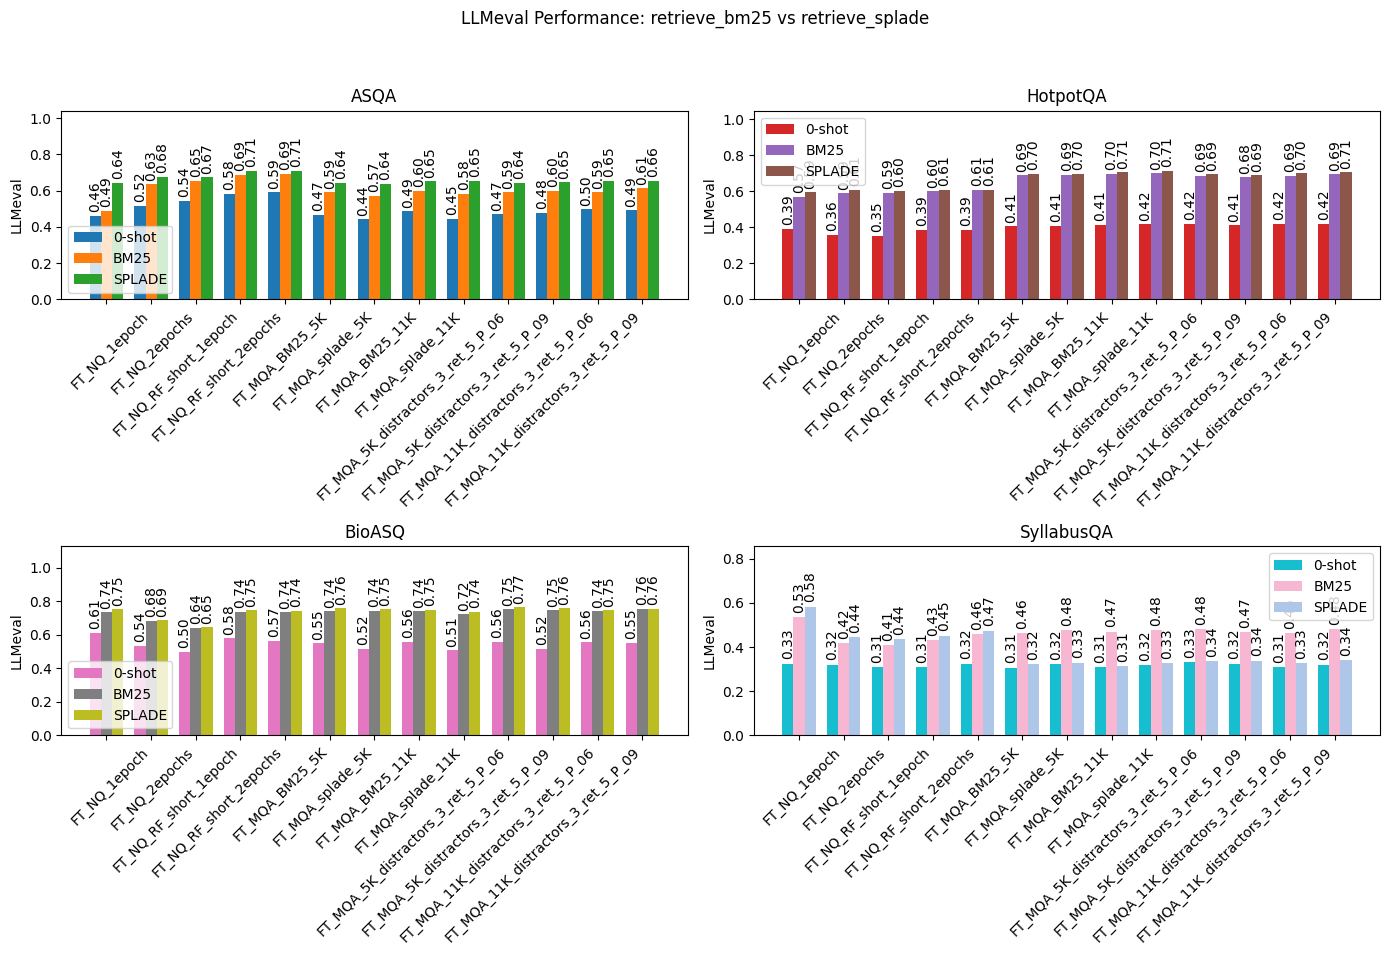

In [9]:
zero_shot_experiments = [
    'll3_8b_0shot',
    'll3_8b_FT_NQ_1epoch_0shot',
    'll3_8b_FT_NQ_2epochs_0shot',
    'll3_8b_FT_NQ_RF_short_1epoch_0shot',
    'll3_8b_FT_NQ_RF_short_2epochs_0shot',
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_splade_5K_0shot',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_splade_11K_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_0shot',
]

bm25_retrieval_experiments = [
    'll3_8b_bm25',
    'll3_8b_FT_NQ_1epoch_bm25',
    'll3_8b_FT_NQ_2epochs_bm25',
    'll3_8b_FT_NQ_RF_short_1epoch_bm25',
    'll3_8b_FT_NQ_RF_short_2epochs_bm25',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_splade_5K_bm25',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_splade_11K_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_bm25',
]

splade_retrieval_experiments = [
    'll3_8b_splade',
    'll3_8b_FT_NQ_1epoch_splade',
    'll3_8b_FT_NQ_2epochs_splade',
    'll3_8b_FT_NQ_RF_short_1epoch_splade',
    'll3_8b_FT_NQ_RF_short_2epochs_splade',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_splade_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_splade',
    'll3_8b_FT_MQA_splade_11K_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_splade',
]


# Dataset names
dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics function
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Function for collecting data
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for 0-shot, BM25, and SPLADE experiments
zero_shot_matches, zero_shot_recalls, zero_shot_llmevals = collect_experiment_data_per_dataset(zero_shot_experiments, dataset_dirs)
bm25_matches, bm25_recalls, bm25_llmevals = collect_experiment_data_per_dataset(bm25_retrieval_experiments, dataset_dirs)
splade_matches, splade_recalls, splade_llmevals = collect_experiment_data_per_dataset(splade_retrieval_experiments, dataset_dirs)

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, zero_shot_data, bm25_data, splade_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    # Define colors for each dataset triplet
    colors = [
        ('#1f77b4', '#ff7f0e', '#2ca02c'),  # Dataset 1 colors (blue, orange, green)
        ('#d62728', '#9467bd', '#8c564b'),  # Dataset 2 colors (red, purple, brown)
        ('#e377c2', '#7f7f7f', '#bcbd22'),  # Dataset 3 colors (pink, gray, yellow)
        ('#17becf', '#f7b6d2', '#aec7e8'),  # Dataset 4 colors (cyan, light pink, light blue)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.25
        x = np.arange(len(experiment_labels))
        
        # Plot bars for 0-shot, BM25, and SPLADE for the dataset
        bar1 = ax.bar(x - bar_width, zero_shot_data[i], bar_width, label='0-shot', color=colors[i][0])
        bar2 = ax.bar(x, bm25_data[i], bar_width, label='BM25', color=colors[i][1])
        bar3 = ax.bar(x + bar_width, splade_data[i], bar_width, label='SPLADE', color=colors[i][2])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        for rect in bar3:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # Adjust y-axis limits to fit numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        
        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()


# Define experiment labels (using only the name part after 'll3_8b_')
experiment_labels = [exp[7:-7] for exp in splade_retrieval_experiments]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', zero_shot_matches, bm25_matches, splade_matches, experiment_labels, 'Match Performance: retrieve_bm25 vs retrieve_splade', dataset_names)
plot_metrics_bar_subplots('Recall', zero_shot_recalls, bm25_recalls, splade_recalls, experiment_labels, 'Recall Performance: retrieve_bm25 vs retrieve_splade', dataset_names)
plot_metrics_bar_subplots('LLMeval', zero_shot_llmevals, bm25_llmevals, splade_llmevals, experiment_labels, 'LLMeval Performance: retrieve_bm25 vs retrieve_splade', dataset_names)

# Distillation

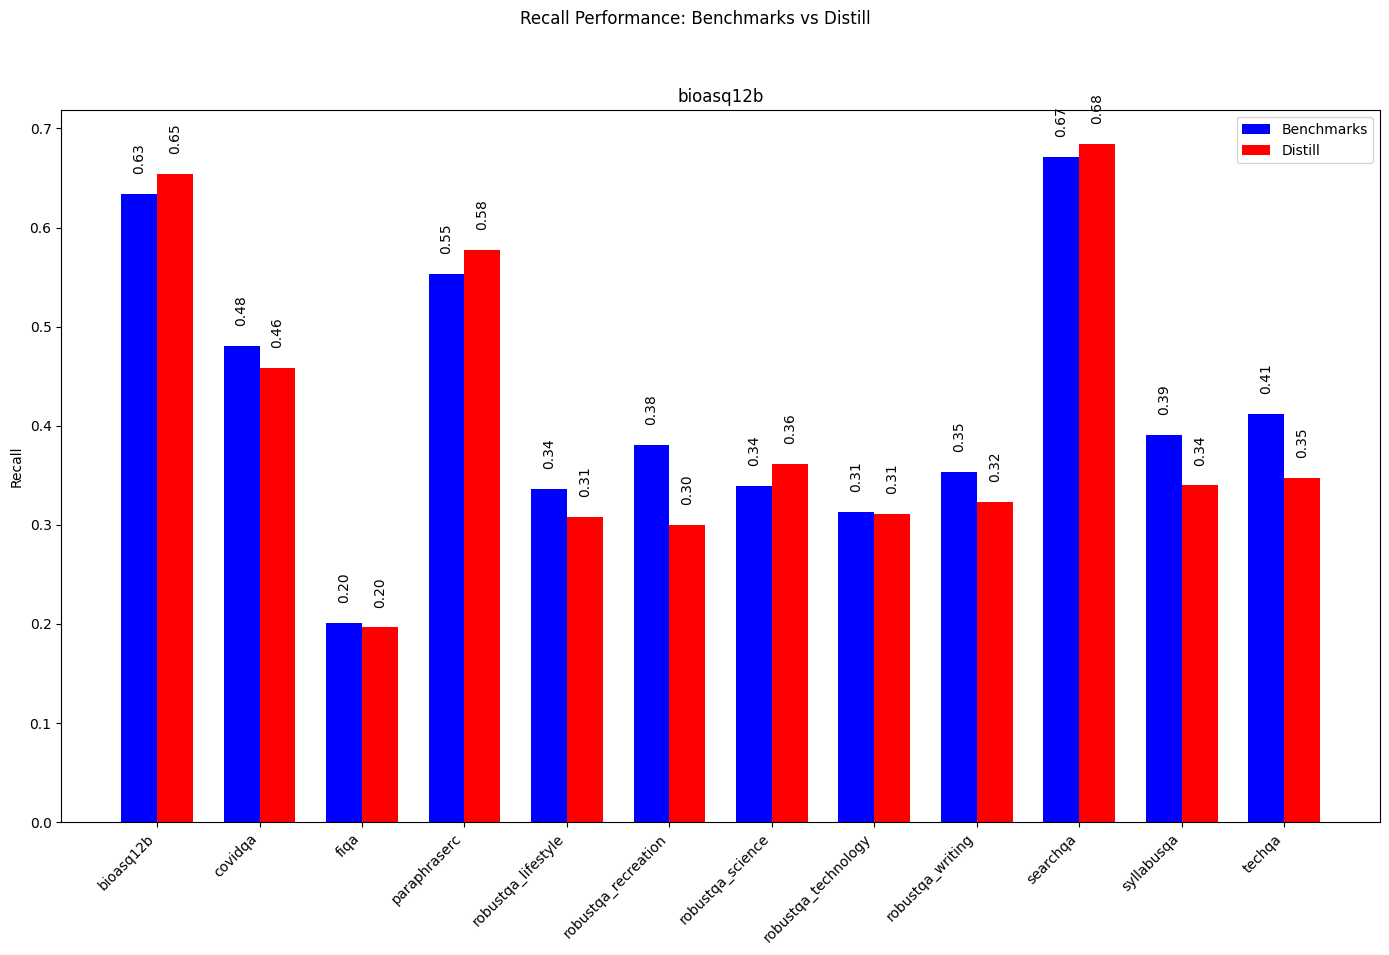

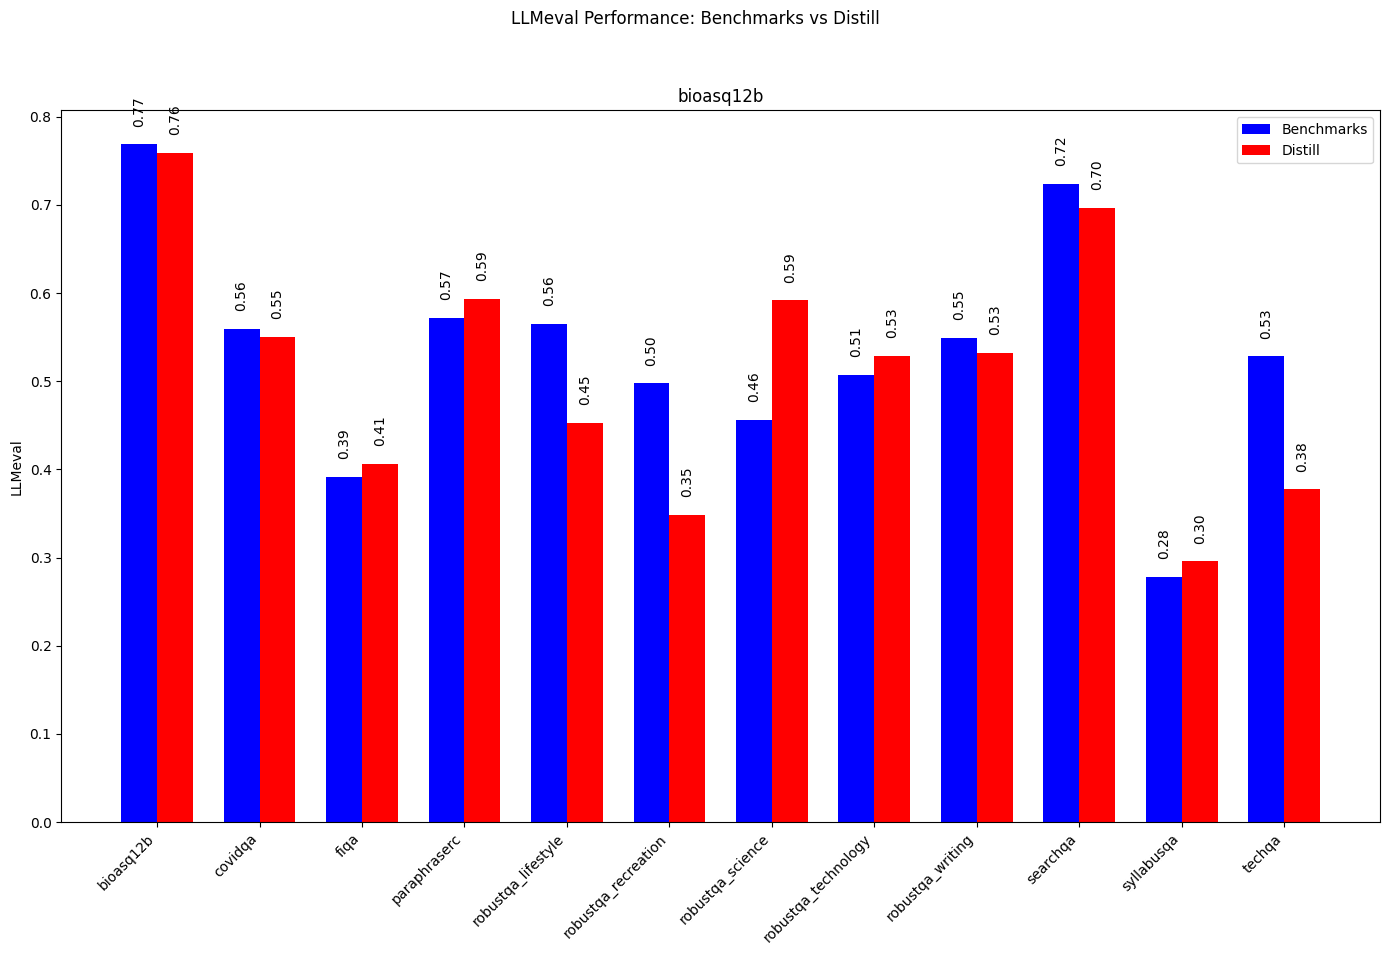

In [2]:
benchmarks_dir = "experiments/benchmarks_qwen"
distill_dir = "experiments/benchmarks_qwen_FT_MultiQA_distilled_mistral7b"

# load all runs in both directories
benchmarks_runs = [f for f in os.listdir(benchmarks_dir) if os.path.isdir(os.path.join(benchmarks_dir, f)) and 'ret' not in f]
distill_runs = [f for f in os.listdir(distill_dir) if os.path.isdir(os.path.join(distill_dir, f))]

def collect_experiment_data(dir, experiments):
    recalls, llmevals = dict(), dict()
    for experiment in experiments:
        if experiment.startswith('robustqa'):
            dataset_name = 'robustqa_' + experiment.split('_')[1]
        else:
            dataset_name = experiment.split('_')[0]
        with open(os.path.join(dir, experiment, 'eval_dev_metrics.json'), 'r') as json_file:
            metrics = json.load(json_file)
        recalls[dataset_name] = metrics['Recall']
        llmevals[dataset_name] = metrics['LLMeval_llama3.1:70b']
    return recalls, llmevals

# Collect data for benchmarks and distill experiments
benchmarks_recalls, benchmarks_llmevals = collect_experiment_data(benchmarks_dir, benchmarks_runs)
distill_recalls, distill_llmevals = collect_experiment_data(distill_dir, distill_runs)

# plot a recall and llmeval bar plot pairing benchmarks and distill next to each other for each dataset

def plot_metrics_bar_subplots(metric_name, benchmarks_data, distill_data, title):

    # sort data alphabetically by dataset name
    benchmarks_data = dict(sorted(benchmarks_data.items()))
    distill_data = dict(sorted(distill_data.items()))
    
    fig, ax = plt.subplots(figsize=(14, 10))

    bar_width = 0.35
    x = np.arange(len(benchmarks_data.keys()))

    # Plot bars for benchmarks and distill for the dataset
    bar1 = ax.bar(x - bar_width/2, benchmarks_data.values(), bar_width, label='Benchmarks', color='b')
    bar2 = ax.bar(x + bar_width/2, distill_data.values(), bar_width, label='Distill', color='r')

    # Add values on top of bars
    for rect in bar1:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

    for rect in bar2:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

    # Configure plot for the dataset
    ax.set_title(list(benchmarks_data.keys())[0].split('_')[0])
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_data.keys(), rotation=45, ha="right")
    ax.set_ylabel(metric_name)
    ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    # plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Recall', benchmarks_recalls, distill_recalls, 'Recall Performance: Benchmarks vs Distill')
plot_metrics_bar_subplots('LLMeval', benchmarks_llmevals, distill_llmevals, 'LLMeval Performance: Benchmarks vs Distill')


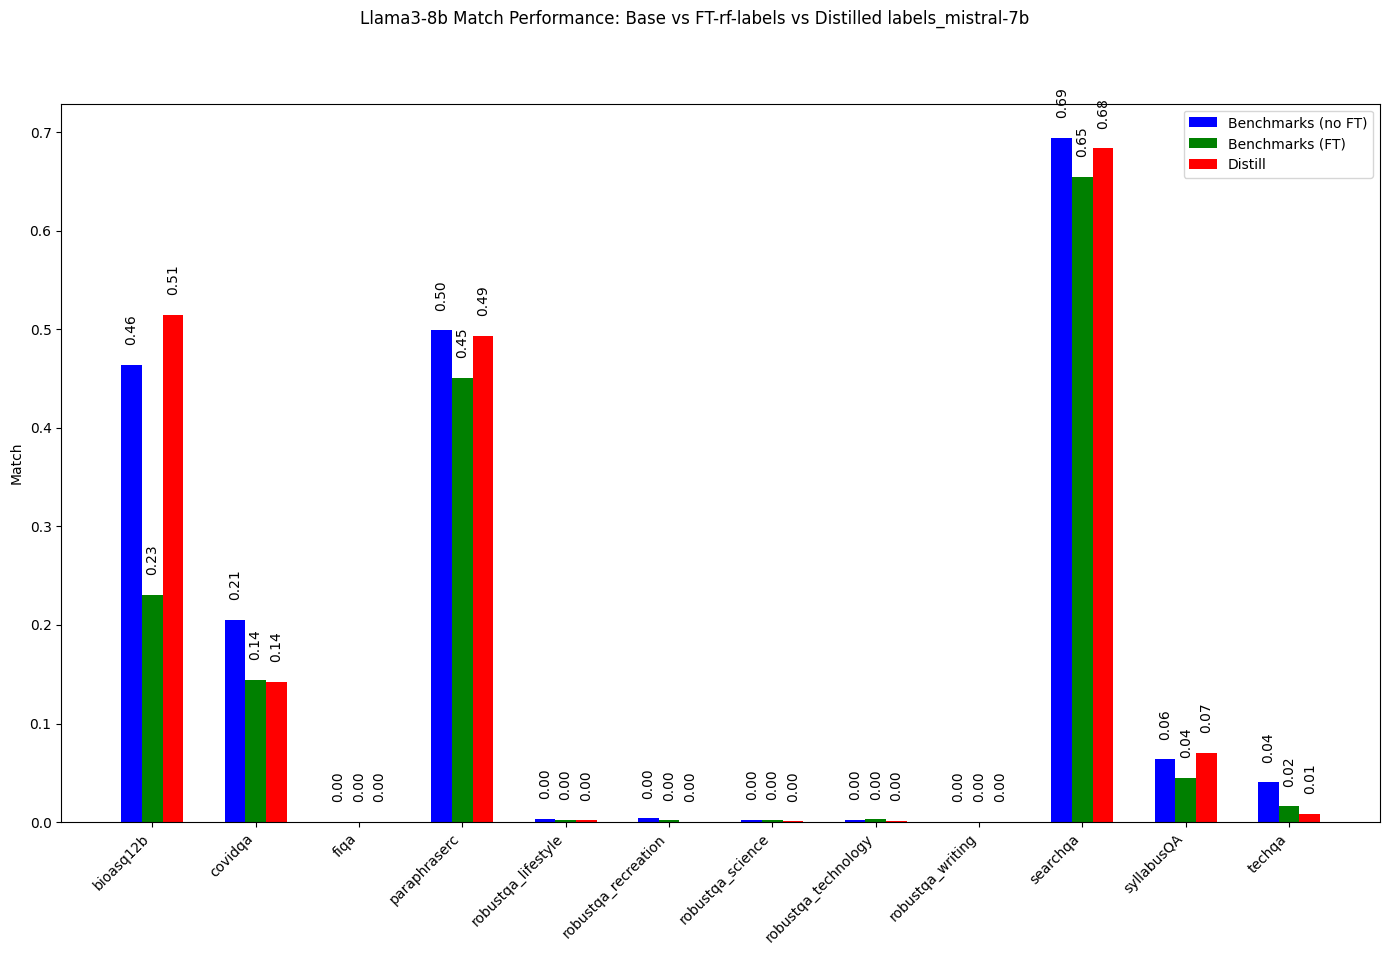

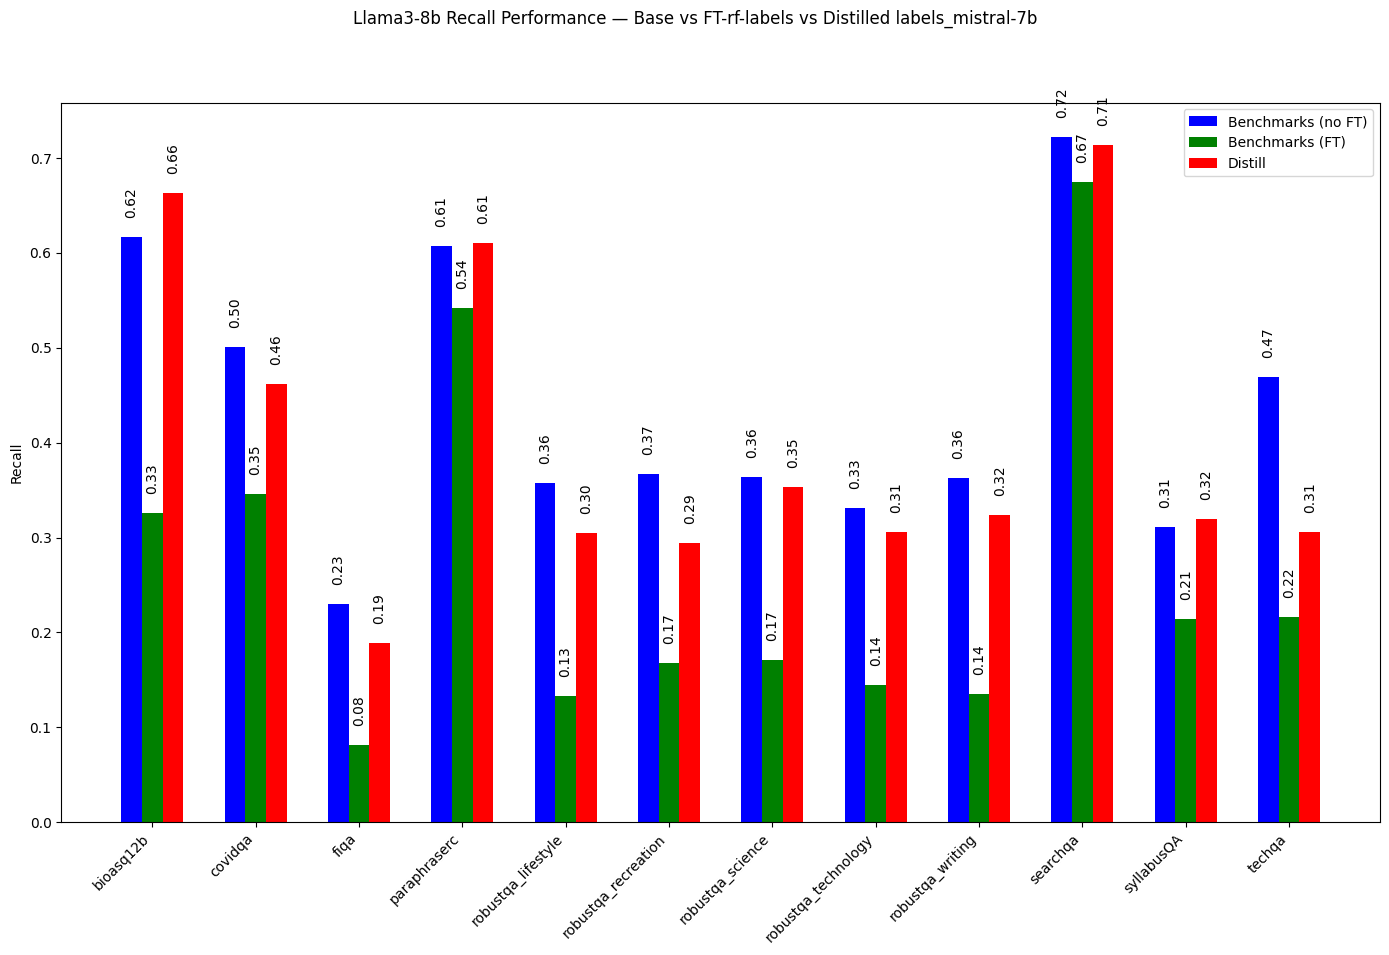

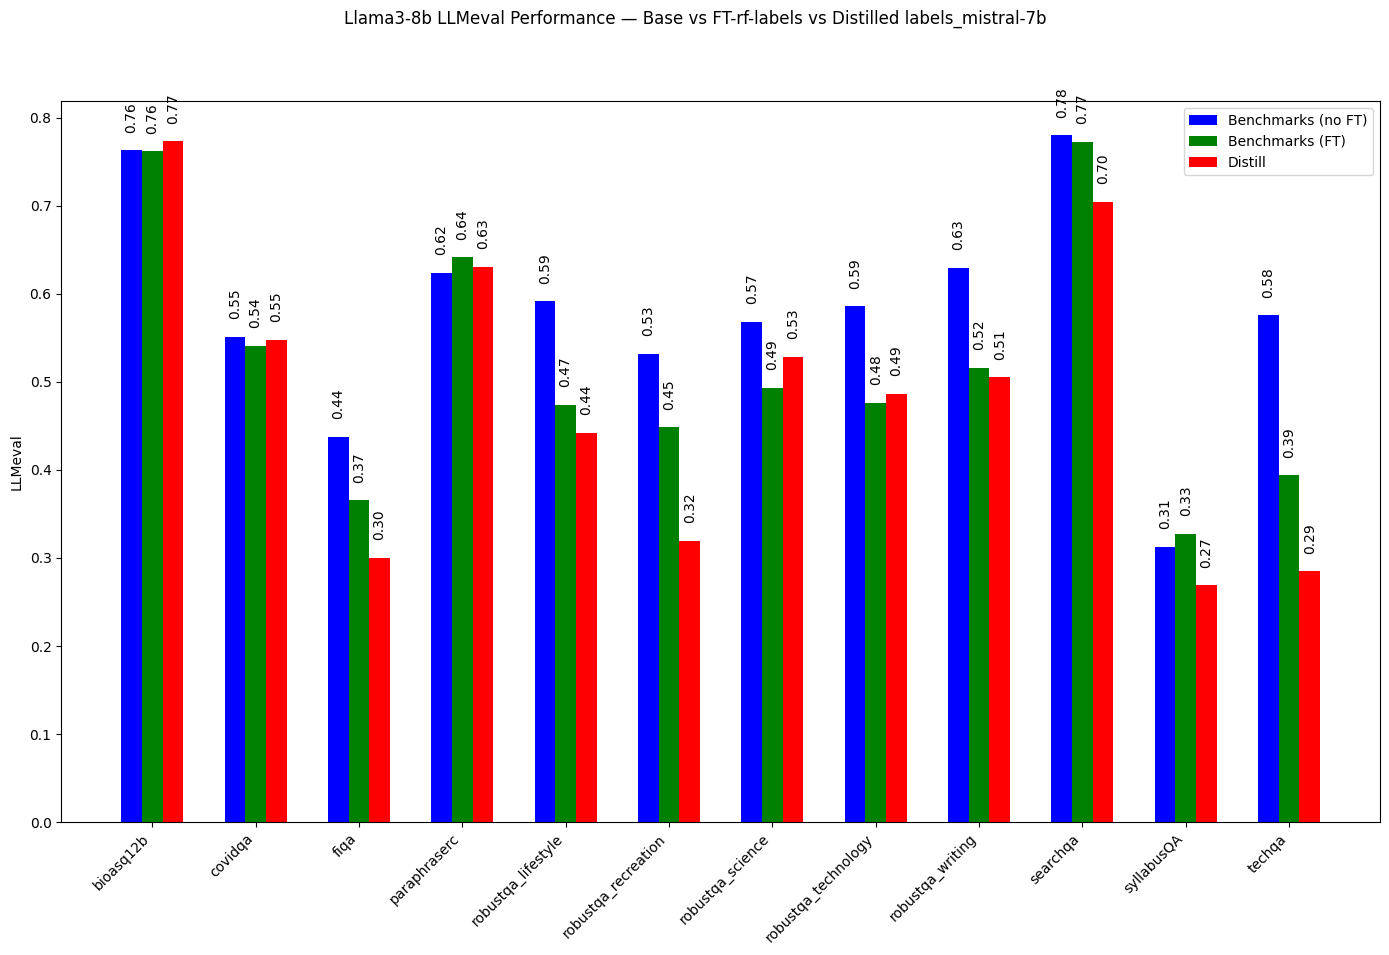

In [7]:
distill_dir = "experiments/benchmarks_llama_FT_MultiQA_distilled_mistral7b"
distill_runs = [f for f in os.listdir(distill_dir) if os.path.isdir(os.path.join(distill_dir, f))]
standard_FT_runs = [
    "experiments/bioasq12b/ll38binstruct_splade_deberta_bioasqprompt_epochs/ll38binstruct_splade_deberta_bioasqprompt_2epoch",
    "experiments/covidqa/ll38binstruct_splade_deberta_covidqaprompt_epochs/ll38binstruct_splade_deberta_covidqaprompt_2epoch",
    "experiments/fiqa/ll38binstruct_splade_deberta_fiqaprompt_epochs/ll38binstruct_splade_deberta_fiqaprompt_2epoch",
    "experiments/paraphraserc/ll38binstruct_splade_deberta_paraphrasercprompt_epochs/ll38binstruct_splade_deberta_paraphrasercprompt_2epoch",
    "experiments/robustqa_lifestyle/ll38binstruct_splade_deberta_lifestyleprompt_epochs/ll38binstruct_splade_deberta_techqaprompt_2epoch",
    "experiments/robustqa_recreation/ll38binstruct_splade_deberta_recreationprompt_epochs/ll38binstruct_splade_deberta_recreationprompt_2epoch",
    "experiments/robustqa_science/ll38binstruct_splade_deberta_scienceprompt_epochs/ll38binstruct_splade_deberta_scienceprompt_2epoch",
    "experiments/robustqa_technology/ll38binstruct_splade_deberta_technologyprompt_epochs/ll38binstruct_splade_deberta_technologyprompt_2epoch",
    "experiments/robustqa_writing/ll38binstruct_splade_deberta_writingprompt_epochs/ll38binstruct_splade_deberta_writingprompt_2epoch",
    "experiments/searchqa/ll38binstruct_splade_deberta_searchqaprompt_epochs/ll38binstruct_splade_deberta_searchqaprompt_2epoch",
    "experiments/syllabusQA/ll38binstruct_splade_deberta_syllabusqaprompt_epochs/ll38binstruct_splade_deberta_syllabusqaprompt_2epoch",
    "experiments/techqa/ll38binstruct_splade_deberta_techqaprompt_epochs/ll38binstruct_splade_deberta_techqaprompt_2epoch",
]
benchmarks_llama_runs = [
    "experiments/bioasq12b/ll3_8b_splade_deberta_bioasqprompt_2",
    "experiments/covidqa/llama3_8b_splade_deberta_covidqaprompt",
    "experiments/fiqa/llama3_8b_splade_deberta_advprompt",
    "experiments/paraphraserc/llama3_8b_splade_deberta_advprompt",
    "experiments/robustqa_lifestyle/llama3_8b_splade_deberta_lifestyleprompt",
    "experiments/robustqa_recreation/llama3_8b_splade_deberta_recreationprompt",
    "experiments/robustqa_science/llama3_8b_splade_deberta_scienceprompt",
    "experiments/robustqa_technology/llama3_8b_splade_deberta_techprompt",
    "experiments/robustqa_writing/llama3_8b_splade_deberta_writingprompt",
    "experiments/searchqa/llama3_8b_splade_deberta_techprompt",
    "experiments/syllabusQA/llama3_8b_splade_deberta_syllqaprompt",
    "experiments/techqa/llama3_8b_splade_deberta_techprompt",
]

def collect_experiment_data(dir, experiments=None):
    matchs, recalls, llmevals = dict(), dict(), dict()
    if experiments is None:
        for d in dir:
            with open(os.path.join(d, 'eval_dev_metrics.json'), 'r') as json_file:
                metrics = json.load(json_file)
            dataset_name = d.split('/')[1]
            matchs[dataset_name] = metrics['M']
            recalls[dataset_name] = metrics['Recall']
            llmevals[dataset_name] = float(metrics['LLMeval_llama3.1:70b'])
    else:
        for experiment in experiments:
            if experiment.startswith('robustqa'):
                dataset_name = 'robustqa_' + experiment.split('_')[1]
            else:
                dataset_name = experiment.split('_')[0]
            with open(os.path.join(dir, experiment, 'eval_dev_metrics.json'), 'r') as json_file:
                metrics = json.load(json_file)
            matchs[dataset_name] = metrics['M']
            recalls[dataset_name] = metrics['Recall']
            llmevals[dataset_name] = float(metrics['LLMeval_llama3.1:70b'])
    return matchs, recalls, llmevals

# Collect data for benchmarks and distill experiments
benchmarks_matches, benchmarks_recalls, benchmarks_llmevals = collect_experiment_data(benchmarks_llama_runs)
benchmarks_FT_matches, benchmarks_FT_recalls, benchmarks_FT_llmevals = collect_experiment_data(standard_FT_runs)
distill_matches, distill_recalls, distill_llmevals = collect_experiment_data(distill_dir, distill_runs)

# plot a recall and llmeval bar plot pairing benchmarks and distill next to each other for each dataset

def plot_metrics_bar_subplots(metric_name, benchmarks_data, benchmarks_FT_data, distill_data, title):

    # sort data alphabetically by dataset name
    benchmarks_data = dict(sorted(benchmarks_data.items()))
    benchmarks_FT_data = dict(sorted(benchmarks_FT_data.items()))
    distill_data = dict(sorted(distill_data.items()))
    
    fig, ax = plt.subplots(figsize=(14, 10))

    bar_width = 0.2
    x = np.arange(len(benchmarks_data.keys()))

    # Plot bars for benchmarks and distill for the dataset
    bar0 = ax.bar(x - bar_width, benchmarks_data.values(), bar_width, label='Benchmarks (no FT)', color='b')
    bar1 = ax.bar(x, benchmarks_FT_data.values(), bar_width, label='Benchmarks (FT)', color='g')
    bar2 = ax.bar(x + bar_width, distill_data.values(), bar_width, label='Distill', color='r')

    for bar in [bar0, bar1, bar2]:
        for rect in bar:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

    # Configure plot for the dataset
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_data.keys(), rotation=45, ha="right")
    ax.set_ylabel(metric_name)
    ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', benchmarks_matches, benchmarks_FT_matches, distill_matches, 'Llama3-8b Match Performance: Base vs FT-rf-labels vs Distilled labels_mistral-7b')
plot_metrics_bar_subplots('Recall', benchmarks_recalls, benchmarks_FT_recalls, distill_recalls, 'Llama3-8b Recall Performance — Base vs FT-rf-labels vs Distilled labels_mistral-7b')
plot_metrics_bar_subplots('LLMeval', benchmarks_llmevals, benchmarks_FT_llmevals, distill_llmevals, 'Llama3-8b LLMeval Performance — Base vs FT-rf-labels vs Distilled labels_mistral-7b')